### 공유자전거 데이터 분석

### 라이브러리 불러오기, 데이터 로드

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

def iqr_bounds(series):
    clean = series.dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lower, upper, int(((clean < lower) | (clean > upper)).sum())

df = pd.read_csv("A_공유자전거_대여운영_dirty.csv")

In [25]:
df.head()

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0


In [26]:
df.shape

(652, 11)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          652 non-null    str    
 1   station_zone       652 non-null    str    
 2   member_type        629 non-null    str    
 3   weather            635 non-null    str    
 4   temperature_c      652 non-null    float64
 5   humidity_pct       627 non-null    float64
 6   wind_speed_mps     652 non-null    float64
 7   distance_km        652 non-null    float64
 8   ride_duration_min  631 non-null    float64
 9   bike_age_months    638 non-null    float64
 10  late_return        652 non-null    int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 56.2 KB


In [28]:
df.describe(include="all")

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
count,652,652,629,635,652.000000,627.000000,652.000000,652.000000,631.000000,638.000000,652.000000
unique,644,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0019,주거,월회원,맑음,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,192,245,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232,0.050613
std,NaN,NaN,NaN,NaN,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047,0.219375
min,NaN,NaN,NaN,NaN,-19.100000,28.000000,0.200000,0.680000,4.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,19.000000,51.750000,2.200000,2.180000,13.500000,14.000000,0.000000
50%,NaN,NaN,NaN,NaN,22.600000,61.500000,3.200000,3.280000,18.600000,22.000000,0.000000
75%,NaN,NaN,NaN,NaN,27.225000,72.100000,4.200000,4.910000,24.900000,29.000000,0.000000


In [29]:
audit = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": df.isna().mean()
})
audit

,missing_count,missing_ratio
rental_id,0,0.000000
station_zone,0,0.000000
member_type,23,0.035276
weather,17,0.026074
temperature_c,0,0.000000
humidity_pct,25,0.038344
wind_speed_mps,0,0.000000
distance_km,0,0.000000
ride_duration_min,21,0.032209
bike_age_months,14,0.021472


In [30]:
df.duplicated().sum()

np.int64(6)

In [31]:
df["rental_id"].duplicated().sum()

np.int64(8)

In [32]:
print("rental_id 중복:", df["rental_id"].duplicated().sum())
# rental_id는 분석 피처가 아니라 대여 건을 구별하는 식별자

rental_id 중복: 8


In [33]:
dedup = df.drop_duplicates().copy()
dedup.shape[0]

646

In [34]:
# rental_id는 같은데 값이 다른 행은 그룹화해서 통합 (late_return은 평균 대신 첫 값 사용)
numeric_cols = dedup.select_dtypes(include="number").columns.difference(["late_return"])

In [35]:
aggregate = {col: "first" for col in dedup.columns if col not in {"rental_id", *numeric_cols}}

In [36]:
aggregate = {}
for col in dedup.columns:
    if col not in {"rental_id", *numeric_cols}:   # rental_id도 아니고, 평균 낼 숫자 컬럼도 아니면
        aggregate[col] = "first"                   # "첫 값을 쓰겠다"고 표시

In [37]:
aggregate.update({col: "mean" for col in numeric_cols})

In [38]:
{
  "station_zone": "first", "member_type": "first", "weather": "first", "late_return": "first",
  "temperature_c": "mean", "humidity_pct": "mean"
}

{'station_zone': 'first',
 'member_type': 'first',
 'weather': 'first',
 'late_return': 'first',
 'temperature_c': 'mean',
 'humidity_pct': 'mean'}

In [39]:
df = dedup.groupby("rental_id", as_index=False, sort=False).agg(aggregate)
df

,rental_id,station_zone,member_type,weather,late_return,bike_age_months,distance_km,humidity_pct,ride_duration_min,temperature_c,wind_speed_mps
0,R0001,공원,일일권,비,0,28.0,4.11,77.0,NaN,31.5,5.6
1,R0002,도심,월회원,흐림,0,33.0,1.35,74.6,11.0,23.3,4.6
2,R0003,공원,일일권,맑음,0,31.0,1.49,56.3,11.6,22.5,1.0
3,R0004,공원,연회원,흐림,0,21.0,6.73,77.3,27.5,28.6,2.0
4,R0005,공원,월회원,맑음,0,42.0,3.09,46.3,17.5,13.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...
639,R0640,주거,월회원,비,0,1.0,1.52,77.7,NaN,30.6,4.8
640,R0641,대학가,일일권,비,0,23.0,6.19,69.4,35.4,25.8,4.6
641,R0642,대학가,연회원,흐림,0,NaN,1.53,80.8,8.6,22.4,5.5
642,R0643,주거,월회원,맑음,0,27.0,3.08,64.0,17.9,31.6,3.4


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          644 non-null    str    
 1   station_zone       644 non-null    str    
 2   member_type        622 non-null    str    
 3   weather            627 non-null    str    
 4   late_return        644 non-null    int64  
 5   bike_age_months    630 non-null    float64
 6   distance_km        644 non-null    float64
 7   humidity_pct       619 non-null    float64
 8   ride_duration_min  623 non-null    float64
 9   temperature_c      644 non-null    float64
 10  wind_speed_mps     644 non-null    float64
dtypes: float64(6), int64(1), str(4)
memory usage: 55.5 KB


In [41]:
for col in ["member_type", "weather"]:
    df[col] = df[col].fillna("미상")
for col in ["humidity_pct", "ride_duration_min", "bike_age_months"]:
    df[col] = df[col].fillna(df[col].median())

df.shape

(644, 11)

In [42]:
df.isnull().sum()

rental_id            0
station_zone         0
member_type          0
weather              0
late_return          0
bike_age_months      0
distance_km          0
humidity_pct         0
ride_duration_min    0
temperature_c        0
wind_speed_mps       0
dtype: int64

<Axes: >

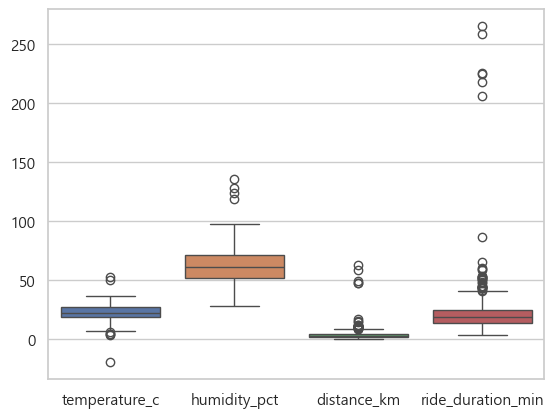

In [43]:
outlier_cols = ["temperature_c", "humidity_pct", "distance_km", "ride_duration_min"]

sns.boxplot(data=df[outlier_cols])

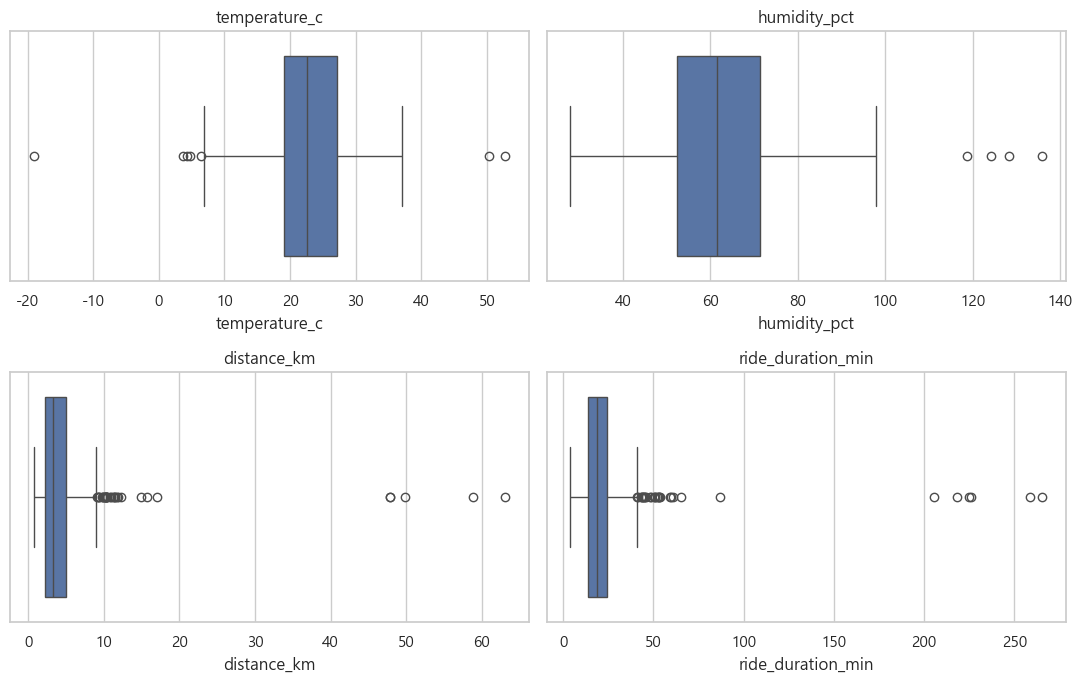

In [44]:
# 컬럼마다 단위(스케일)가 달라서 한 그래프에 모아 그리면 서로 비교가 잘 안 됨
# -> 컬럼별로 따로 그려서 각자의 분포를 자세히 확인
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, ax in zip(outlier_cols, axes.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()

In [45]:
bounds = {}
for col in outlier_cols:
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    bounds[col] = {"lower": lower, "upper": upper, "outlier_count": count}

pd.DataFrame(bounds).T

,lower,upper,outlier_count
temperature_c,6.700,39.500,7.0
humidity_pct,23.800,99.800,4.0
distance_km,-1.915,9.005,33.0
ride_duration_min,-2.750,40.850,31.0


In [46]:
# 습도는 0~100% 범위를 벗어나면 명백한 오류 -> capping
df["humidity_range_error"] = (~df["humidity_pct"].between(0, 100)).astype("int8")
df["humidity_pct"] = df["humidity_pct"].clip(0, 100)

In [47]:
# 나머지는 실제로 있을 수 있는 값이므로 원본은 유지하고 이상치 여부만 플래그로 남김
for col in ["temperature_c", "distance_km", "ride_duration_min"]:
    lower, upper, _ = iqr_bounds(df[col])
    df[f"{col}_outlier"] = ((df[col] < lower) | (df[col] > upper)).astype("int8")

In [48]:
df[["humidity_range_error", "temperature_c_outlier", "distance_km_outlier", "ride_duration_min_outlier"]].sum()

humidity_range_error          4
temperature_c_outlier         7
distance_km_outlier          33
ride_duration_min_outlier    31
dtype: int64

In [49]:
df["avg_speed_kmh"] = df["distance_km"].div(df["ride_duration_min"].div(60))
df["avg_speed_kmh"].describe()

count    644.000000
mean      12.866638
std       22.046862
min        0.420029
25%        9.267358
50%       11.093866
75%       12.867059
max      360.800000
Name: avg_speed_kmh, dtype: float64

In [50]:
# 0으로 나누거나 inf가 생기지 않았는지 확인
np.isfinite(df["avg_speed_kmh"]).all()

np.True_

In [51]:
df["speed_outlier"] = df["avg_speed_kmh"].gt(60).astype("int")
df["speed_outlier"].sum()

np.int64(5)

In [52]:
df['bad_weather'] = df['weather'].eq('비').astype('int8')
df['old_bike'] = df['bike_age_months'].gt(df['bike_age_months'].median()).astype('int8')

In [53]:
model_df = pd.get_dummies(df, columns=['station_zone', 'member_type', 'weather'], dtype='int8') 

In [54]:
scale_cols = ["temperature_c", "humidity_pct", "wind_speed_mps", "distance_km",
              "ride_duration_min", "bike_age_months", "avg_speed_kmh"]

model_df[scale_cols] = StandardScaler().fit_transform(model_df[scale_cols])
model_df[scale_cols].describe().loc[["mean", "std"]]

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,avg_speed_kmh
mean,-1.875656e-16,-2.813484e-16,-3.034150e-16,-9.102450e-17,5.516636e-17,6.068300e-17,-1.434325e-16
std,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00


In [55]:
model_df.to_csv('A_공유자전거_cleaned.csv', index=False)
print('저장 완료:',model_df.shape)

저장 완료: (644, 28)
